## Step 1 — Crop Images and Clean Dataset

#### This notebook performs initial preprocessing of the captured RGB and depth images.

## Tasks performed:
#### - Crop the upper portion of images containing the tree canopy
#### - Crop corresponding depth arrays
#### - Match images with digital odometry data
#### - Remove images not associated with digital odometer records

In [1]:
# =========================================================
# Import required libraries
# =========================================================
import os
import shutil
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import pandas as pd
from pathlib import Path
from datetime import datetime

## Shows the image with a pixel grid, to know where to crop

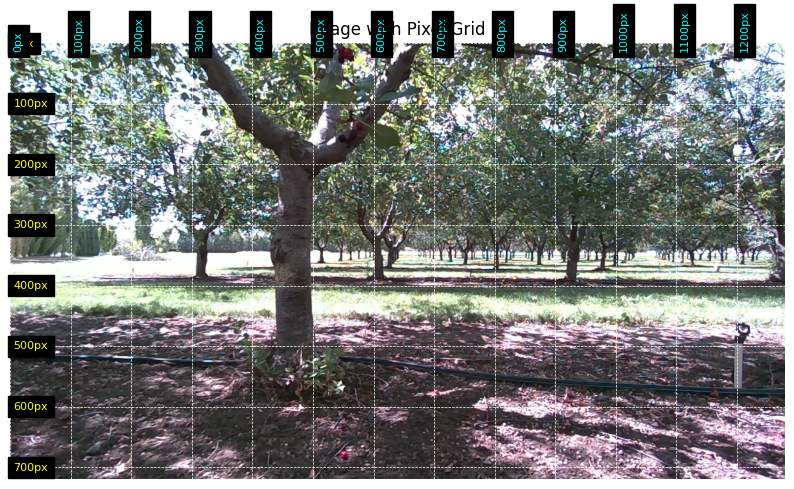

In [18]:
def show_image_with_pixel_grid(image_path, grid_spacing=(100, 100)):
    """
    Display an image with pixel-based grid lines and pixel labels.

    Parameters
    ----------
    image_path : str
        Path to the image file.
    grid_spacing : tuple, optional
        Grid spacing in pixels as (row_spacing, col_spacing).
    """
    img = mpimg.imread(image_path)
    height, width = img.shape[:2]

    fig, ax = plt.subplots(figsize=(10, 8))
    ax.imshow(img)

    row_spacing, col_spacing = grid_spacing

    # Draw horizontal grid lines and labels
    for y in range(0, height, row_spacing):
        ax.axhline(y, color='white', linestyle='--', linewidth=0.5)
        ax.text(5, y + 5, f'{y}px', color='yellow', fontsize=8, backgroundcolor='black')

    # Draw vertical grid lines and labels
    for x in range(0, width, col_spacing):
        ax.axvline(x, color='white', linestyle='--', linewidth=0.5)
        ax.text(x + 5, 10, f'{x}px', color='cyan', fontsize=8, rotation=90, backgroundcolor='black')

    ax.set_title(f"Image with Pixel Grid: {os.path.basename(image_path)}")
    ax.set_xlabel("Width (pixels)")
    ax.set_ylabel("Height (pixels)")
    plt.show()

## Crop top portion of PNG images and save to a new folder

In [20]:
# =========================================================
# Crop the top portion of RGB images and save to a new folder
# =========================================================

def crop_and_move_images(source_folder, destination_folder, crop_start_y=225):
    """
    Crop the top portion of image files and save the cropped images
    to a destination folder.

    Parameters
    ----------
    source_folder : str
        Folder containing the original images.

    destination_folder : str
        Folder where cropped images will be saved.

    crop_start_y : int
        Pixel row where cropping begins. Everything above this
        value is removed.
    """

    # Create the destination folder if it does not exist
    if not os.path.exists(destination_folder):
        os.makedirs(destination_folder)

    files = os.listdir(source_folder)

    for file_name in files:

        if file_name.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp')):

            image_path = os.path.join(source_folder, file_name)

            with Image.open(image_path) as img:

                width, height = img.size

                if crop_start_y >= height:
                    print(f"Skipping {file_name} — crop_start_y ({crop_start_y}) >= image height ({height})")
                    continue

                cropped_img = img.crop((0, crop_start_y, width, height))

                save_path = os.path.join(destination_folder, file_name)
                cropped_img.save(save_path)

                print(f"Cropped and saved: {file_name}")


# Example usage
source_folder = "path/to/original_images"
destination_folder = "path/to/cropped_images"

crop_and_move_images(source_folder, destination_folder, crop_start_y=225)


Cropped and saved: 2025-09-11-11-35-01.0.png
Cropped and saved: 2025-09-11-11-57-04.0.png
Cropped and saved: 2025-09-11-11-57-48.0.png
Cropped and saved: 2025-09-11-11-57-51.0.png
Cropped and saved: 2025-09-11-11-57-54.0.png
Cropped and saved: 2025-09-11-11-58-01.0.png
Cropped and saved: 2025-09-11-11-58-10.0.png
Cropped and saved: 2025-09-11-11-58-18.0.png
Cropped and saved: 2025-09-11-11-58-21.0.png
Cropped and saved: 2025-09-11-11-58-25.0.png
Cropped and saved: 2025-09-11-11-58-26.0.png
Cropped and saved: 2025-09-11-11-58-31.0.png
Cropped and saved: 2025-09-11-11-58-35.0.png
Cropped and saved: 2025-09-11-11-58-37.0.png
Cropped and saved: 2025-09-11-11-58-43.0.png
Cropped and saved: 2025-09-11-11-59-14.0.png
Cropped and saved: 2025-09-11-11-59-18.0.png
Cropped and saved: 2025-09-11-11-59-42.0.png
Cropped and saved: 2025-09-11-11-59-52.0.png
Cropped and saved: 2025-09-11-12-00-03.0.png
Cropped and saved: 2025-09-11-12-00-30.0.png
Cropped and saved: 2025-09-11-12-00-36.0.png
Cropped an

## Crop top portion of NPY depth images and save to a new folder

In [21]:
# =========================================================
# Crop the top portion of depth images (.npy) and save to
# a new folder
# =========================================================

def crop_and_move_npy_images(source_folder, destination_folder, crop_start_y=225):
    """
    Crop the top portion of depth images stored as NumPy arrays
    and save the cropped arrays to a destination folder.
    """

    if not os.path.exists(destination_folder):
        os.makedirs(destination_folder)

    files = os.listdir(source_folder)

    for file_name in files:

        if file_name.lower().endswith(".npy"):

            file_path = os.path.join(source_folder, file_name)

            depth_image = np.load(file_path)

            height = depth_image.shape[0]

            if crop_start_y >= height:
                print(f"Skipping {file_name} — crop_start_y ({crop_start_y}) >= image height ({height})")
                continue

            cropped_image = depth_image[crop_start_y:, :]

            save_path = os.path.join(destination_folder, file_name)
            np.save(save_path, cropped_image)

            print(f"Cropped and saved: {file_name}")


# Example usage
source_folder = "path/to/original_depth_arrays"
destination_folder = "path/to/cropped_depth_arrays"

crop_and_move_npy_images(source_folder, destination_folder, crop_start_y=225)

Cropped and saved: 2025-09-11-11-57-11.0.npy
Cropped and saved: 2025-09-11-11-57-14.0.npy
Cropped and saved: 2025-09-11-11-57-16.0.npy
Cropped and saved: 2025-09-11-11-57-19.0.npy
Cropped and saved: 2025-09-11-11-57-21.0.npy
Cropped and saved: 2025-09-11-11-57-41.0.npy
Cropped and saved: 2025-09-11-11-57-58.0.npy
Cropped and saved: 2025-09-11-11-58-09.0.npy
Cropped and saved: 2025-09-11-11-58-14.0.npy
Cropped and saved: 2025-09-11-11-58-17.0.npy
Cropped and saved: 2025-09-11-11-58-24.0.npy
Cropped and saved: 2025-09-11-11-58-26.0.npy
Cropped and saved: 2025-09-11-11-58-46.0.npy
Cropped and saved: 2025-09-11-11-58-49.0.npy
Cropped and saved: 2025-09-11-11-58-50.0.npy
Cropped and saved: 2025-09-11-11-58-54.0.npy
Cropped and saved: 2025-09-11-11-58-57.0.npy
Cropped and saved: 2025-09-11-11-58-59.0.npy
Cropped and saved: 2025-09-11-11-59-02.0.npy
Cropped and saved: 2025-09-11-11-59-03.0.npy
Cropped and saved: 2025-09-11-11-59-07.0.npy
Cropped and saved: 2025-09-11-11-59-09.0.npy
Cropped an

## Matches speedometer data with image data

In [2]:
# =========================================================
# Match image timestamps to speedometer data
# =========================================================

# === CONFIGURATION ===
image_folder = Path("path/to/image_folder")
speedo_file = "path/to/Speedometer_only.csv"
output_file = image_folder / "image_matchto_distances.csv"

# Example image name: 2025-04-08-13-06-13.6.png
IMAGE_STEM_DT_FORMAT = "%Y-%m-%d-%H-%M-%S.%f"


def extract_timestamp(p: Path) -> datetime:
    """Extract timestamp from an image filename stem."""
    return datetime.strptime(p.stem, IMAGE_STEM_DT_FORMAT)


def parse_speedo_times(df_speedo: pd.DataFrame, date_for_times) -> pd.Series:
    """Convert speedometer time strings to datetimes using the image date."""
    parsed = pd.to_datetime(df_speedo["Time"], format="%I:%M:%S %p", errors="coerce")
    return parsed.apply(
        lambda t: datetime.combine(date_for_times, t.time()) if pd.notnull(t) else pd.NaT
    )


# === 1) LOAD IMAGES ===
image_files = sorted(image_folder.glob("*.png"))

if not image_files:
    raise FileNotFoundError(f"No PNG images found in {image_folder}")

img_df = pd.DataFrame({
    "Image_Name": [p.name for p in image_files],
    "Image_Timestamp_dt": [extract_timestamp(p) for p in image_files],
})

# Temporary aligned second used for matching, not saved
img_df["Aligned_TS"] = img_df["Image_Timestamp_dt"].dt.floor("s")


# === 2) LOAD SPEEDOMETER DATA ===
spd = pd.read_csv(speedo_file)
spd["Distance (m)"] = pd.to_numeric(spd.get("Distance (m)"), errors="coerce")
spd["row"] = pd.to_numeric(spd.get("row"), errors="coerce")

first_image_date = img_df["Image_Timestamp_dt"].iloc[0].date()
spd["Timestamp"] = parse_speedo_times(spd, first_image_date)
spd = spd.dropna(subset=["Timestamp"]).sort_values("Timestamp")


# === 3) CLIP IMAGES TO SPEEDOMETER TIME WINDOW ===
tmin, tmax = spd["Timestamp"].min(), spd["Timestamp"].max()

img_clip = img_df[
    (img_df["Aligned_TS"] >= tmin) & (img_df["Aligned_TS"] <= tmax)
].copy()

img_clip = img_clip.sort_values("Aligned_TS")


# === 4) MERGE USING BACKWARD MATCH WITH 1-SECOND TOLERANCE ===
merged = pd.merge_asof(
    left=img_clip[["Image_Name", "Image_Timestamp_dt", "Aligned_TS"]].sort_values("Aligned_TS"),
    right=spd[["Timestamp", "Distance (m)", "row"]].sort_values("Timestamp"),
    left_on="Aligned_TS",
    right_on="Timestamp",
    direction="backward",
    tolerance=pd.Timedelta("1s"),
)

merged = merged.dropna(subset=["Timestamp"]).copy()
merged.rename(columns={"row": "Row"}, inplace=True)
merged["Row"] = merged["Row"].astype("Int64")


# === 5) RESET DISTANCE WITHIN EACH ROW AND FORMAT OUTPUT ===
# Keep original cumulative distance
merged["Distance_total (m)"] = merged["Distance (m)"]

# Reset distance within each row
first_by_row = merged.groupby("Row")["Distance_total (m)"].transform("first")
merged["Distance (m)"] = (merged["Distance_total (m)"] - first_by_row).clip(lower=0)


def fmt_mm_ss_tenth(ts: pd.Timestamp) -> str:
    """Format timestamp as MM:SS.tenths."""
    if pd.isna(ts):
        return ""
    minute = ts.minute
    second = ts.second
    tenth = int(ts.microsecond / 100000)
    return f"{minute:02d}:{second:02d}.{tenth}"


def fmt_mdY_HM(ts: pd.Timestamp) -> str:
    """Format timestamp as m/d/YYYY HH:MM."""
    if pd.isna(ts):
        return ""
    return f"{ts.month}/{ts.day}/{ts.year} {ts.hour:02d}:{ts.minute:02d}"


merged["Image_Timestamp"] = merged["Image_Timestamp_dt"].apply(fmt_mm_ss_tenth)
merged["Timestamp"] = merged["Timestamp"].apply(fmt_mdY_HM)


# === 6) ORDER COLUMNS AND SAVE ===
out = merged[[
    "Image_Name",
    "Image_Timestamp",
    "Timestamp",
    "Distance_total (m)",
    "Distance (m)",
    "Row",
]].sort_values(["Row", "Image_Name"])

out.to_csv(output_file, index=False)
print(f"Saved: {output_file}")

✅ Saved: D:\DepthImages\Blocks\Kaysville\091125\left\image_matchto_distances.csv


### Delete .png and .npy files not associated with speedometer data

In [4]:
# =========================================================
# Delete image and depth files not included in matched CSV
# =========================================================

# === CONFIGURATION ===
image_folder = Path("path/to/image_folder")
csv_file = image_folder / "image_matchto_distances.csv"


# === 1) LOAD CSV AND GET VALID IMAGE STEMS ===
df = pd.read_csv(csv_file)
df["Image_Name"] = df["Image_Name"].astype(str).str.strip()

# Use stems only so matching works for both .png and .npy files
valid_stems = set(Path(name).stem for name in df["Image_Name"].tolist())


# === 2) DELETE FILES NOT FOUND IN CSV ===
deleted = 0

for file in image_folder.iterdir():
    if file.suffix.lower() not in [".png", ".npy"]:
        continue

    if file.stem not in valid_stems:
        try:
            file.unlink()
            print(f"Deleted: {file.name}")
            deleted += 1
        except PermissionError:
            print(f"Permission denied (in use?): {file.name}")


# === 3) SUMMARY ===
print(f"Finished. {deleted} file(s) deleted from {image_folder}")

Deleted: 2025-09-11-13-41-00.1.npy
Deleted: 2025-09-11-13-41-01.0.npy
Deleted: 2025-09-11-13-41-02.0.npy
Deleted: 2025-09-11-13-41-03.0.npy
Deleted: 2025-09-11-13-41-04.0.npy
Deleted: 2025-09-11-13-41-05.0.npy
Deleted: 2025-09-11-13-41-06.0.npy
Deleted: 2025-09-11-13-41-07.0.npy
Deleted: 2025-09-11-13-41-08.0.npy
Deleted: 2025-09-11-13-41-09.0.npy
Deleted: 2025-09-11-13-41-10.0.npy
Deleted: 2025-09-11-13-41-11.0.npy
Deleted: 2025-09-11-13-41-12.0.npy
Deleted: 2025-09-11-13-41-13.0.npy
Deleted: 2025-09-11-13-41-14.0.npy
Deleted: 2025-09-11-13-41-15.0.npy
Deleted: 2025-09-11-13-42-50.0.npy
Deleted: 2025-09-11-13-42-51.0.npy
Deleted: 2025-09-11-13-42-52.0.npy
Deleted: 2025-09-11-13-42-53.0.npy
Deleted: 2025-09-11-13-42-54.0.npy
Deleted: 2025-09-11-13-42-55.0.npy
Deleted: 2025-09-11-13-42-56.0.npy
Deleted: 2025-09-11-13-42-57.0.npy
Deleted: 2025-09-11-13-42-58.0.npy
Deleted: 2025-09-11-13-42-59.0.npy
Deleted: 2025-09-11-13-43-00.0.npy
Deleted: 2025-09-11-13-43-01.0.npy
Deleted: 2025-09-11-